# Resume Parsing System — Model Training & Evaluation

**NLP Project | Resume Classification using LSTM & Transformers**

This notebook covers:
1. Dataset loading and exploration
2. Text preprocessing
3. LSTM model — training and evaluation
4. BERT (Transformer) model — training and evaluation
5. Model comparison
6. Single resume prediction demo

## 0. Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install tensorflow transformers scikit-learn pandas matplotlib seaborn

import subprocess
import sys
from pathlib import Path
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import clean_text
from classifier import ResumeClassifier

dataset_path = Path('../data/resume_dataset.csv')
if not dataset_path.exists():
    subprocess.run([sys.executable, '../scripts/generate_resume_dataset.py'], check=True)

print('All imports successful!')

All imports successful!


## 1. Dataset Exploration

In [2]:
# Load the local training dataset

df = pd.read_csv('../data/resume_dataset.csv')

possible_label = [c for c in df.columns if 'job_position_name' in c]
if possible_label:
    df['Category'] = df[possible_label[0]]
    print(f"Using '{possible_label[0]}' as label column.")
else:
    print("Warning: 'job_position_name' column not found. Available columns:", list(df.columns))
    
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Using '﻿job_position_name' as label column.
Dataset shape: (9544, 37)
Columns: ['address', 'resume_text', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'Resume_str', 'Category']


,address,resume_text,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,Resume_str,Category
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000,Big data analytics working and database wareho...,Senior Software Engineer
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000,Fresher looking to join as a data analyst and ...,Machine Learning (ML) Engineer
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667,"['Software Development', 'Machine Learning', ...","Executive/ Senior Executive- Trade Marketing, ..."
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000,To obtain a position in a fast-paced business ...,Business Development Executive
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000,Professional accountant with an outstanding wo...,Senior iOS Engineer


In [3]:
# How many resumes per category?
target_col = [c for c in df.columns if 'job' in c.lower() and 'position' in c.lower()][0]

print(f'Using column: {target_col}')
print('Category distribution:')
print(df[target_col].value_counts())

print(f'\nTotal categories: {df[target_col].nunique()}')

Using column: ﻿job_position_name
Category distribution:
﻿job_position_name
Site Engineer                                                                              342
Project Coordinator (Civil)                                                                342
Civil Engineer                                                                             342
HR Officer                                                                                 342
Marketing Officer                                                                          341
Manager- Human Resource Management (HRM)\n                                                 341
Head of Internal Control & Compliance (ICC) - SEVP/DMD                                     341
Management Trainee - Mechanical                                                            341
Sr.Officer / Executive - Internal Audit                                                    341
Executive - VAT                                                       

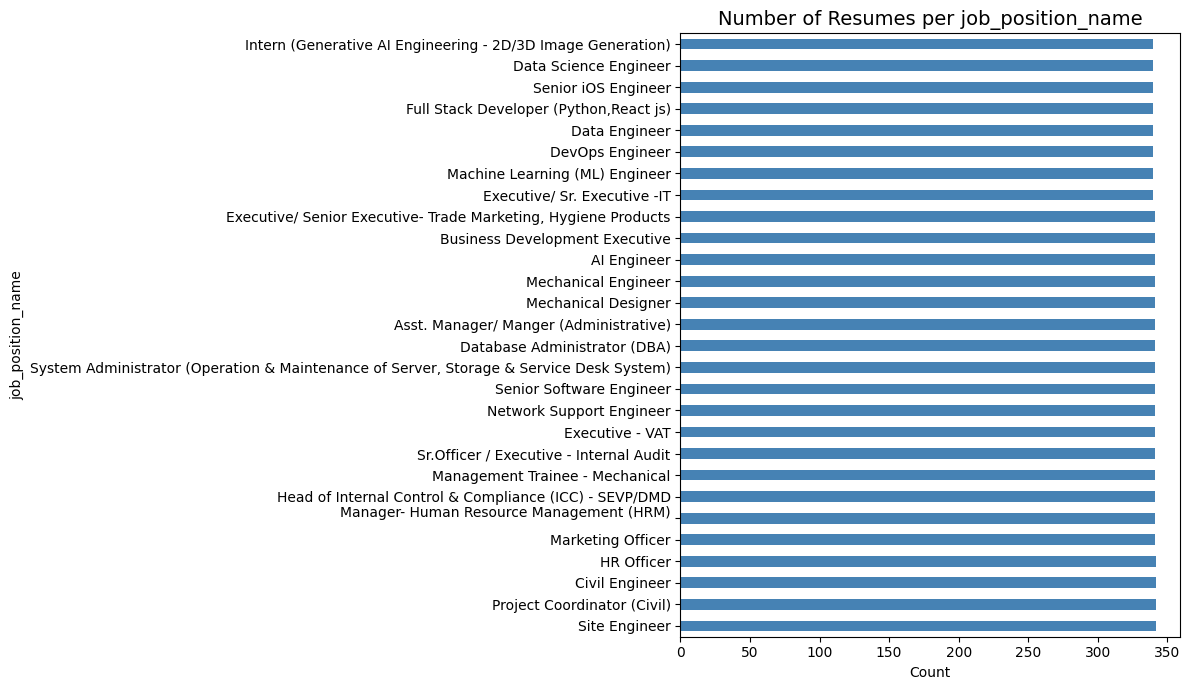

In [4]:
# Visualize distribution
import os
os.makedirs('../docs', exist_ok=True)

# Use the dynamic selection logic to be safe from hidden characters
target_col = [c for c in df.columns if 'job' in c.lower() and 'position' in c.lower()][0]
fig, ax = plt.subplots(figsize=(12, 7))
df[target_col].value_counts().plot(kind='barh', ax=ax, color='steelblue')

ax.set_title(f'Number of Resumes per {target_col}', fontsize=14)
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('../docs/label_distribution.png', dpi=150)
plt.show()

## 2. Text Preprocessing

In [5]:
# Show the effect of cleaning on a sample resume
sample_raw = df['Resume_str'].iloc[0]
sample_clean = clean_text(sample_raw)

print('=== RAW TEXT (first 500 chars) ===')
print(sample_raw[:500])
print()
print('=== CLEANED TEXT (first 500 chars) ===')
print(sample_clean[:500])
print()
print(f'Raw length  : {len(sample_raw.split())} words')
print(f'Clean length: {len(sample_clean.split())} words')

=== RAW TEXT (first 500 chars) ===
Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Micr

=== CLEANED TEXT (first 500 chars) ===
big data analytics working database warehouse manager robust experience handling all kinds data used multiple cloud infrastructure services am well acquainted currently search role offers development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c++ data structures dbms rdbms informatica talend amazon redshift microsoft azure

Raw length  : 69 words
Clean length:

## 3. LSTM Model — Training

In [7]:
# Initialize and train the LSTM classifier
lstm_clf = ResumeClassifier(model_type='lstm')
lstm_clf.train('../data/resume_dataset.csv')

[✓] Loaded 9544 resumes from '../data/resume_dataset.csv'
    Text column  : resume_text
    Label column : positions
    Categories   : 302
    Classes      : ["['Accountant I', 'Intern', 'Security Officer']", "['Accountant II', 'Accountant', 'Financial Service Representative/Back-up Supervisor']", "['Accountant III', 'Assistant Accountant', 'Accounting Clerk B', 'Accounting Instructor', 'Student Accounts Representative/Bookkeeper']", "['Accountant', 'Accountant - Payables / Accounting Clerk', 'Junior Accountant', 'Accountant cum Secretary']", "['Accountant', 'Accountant', 'Accountant', 'Accountant', 'Account Assistant', 'Account Assistant']", "['Accountant', 'Accountant', 'Accountant', 'Accountant']", "['Accountant', 'Accountant', 'Accounting Manager', 'Staff Accountant Finance Manager']", "['Accountant', 'Accountant', 'Bookkeeper', 'Controller Assistant', 'Controller']", "['Accountant', 'Accountant', 'Staff Accountant/ Lease Administrator', 'Assistant Claim Approver', 'Proof Operato

ValueError: The following argument(s) are not supported with the native Keras format: ['options']

## 4. LSTM Model — Evaluation

In [ ]:
# Evaluate: accuracy + confusion matrix + training curves
lstm_accuracy = lstm_clf.evaluate(save_plots=True)
print(f'\nFinal LSTM Test Accuracy: {lstm_accuracy * 100:.2f}%')


1/2 [==============>...............] - ETA: 0s


2/2 [==============================] - 0s 31ms/step



  TEST ACCURACY : 87.18%

Classification Report:
                  precision    recall  f1-score   support

Business Analyst       1.00      1.00      1.00         5
  Data Scientist       1.00      1.00      1.00         4
 DevOps Engineer       0.00      0.00      0.00         5
   HR Specialist       1.00      1.00      1.00         5
  Java Developer       1.00      1.00      1.00         5
Network Engineer       0.50      1.00      0.67         5
Python Developer       1.00      1.00      1.00         5
  UI UX Designer       1.00      1.00      1.00         5

        accuracy                           0.87        39
       macro avg       0.81      0.88      0.83        39
    weighted avg       0.81      0.87      0.83        39

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System/docs/confusion_matrix_lstm.png


/Users/aaa/Desktop/uni/Resume-Parsing-System/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaa/Desktop/uni/Resume-Parsing-System/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaa/Desktop/uni/Resume-Parsing-System/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System/docs/training_curves_lstm.png

Final LSTM Test Accuracy: 87.18%


/Users/aaa/Desktop/uni/Resume-Parsing-System/notebooks/../src/classifier.py:365: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. BERT (Transformer) Model — Training

In [ ]:
# Train BERT — this takes longer but achieves higher accuracy
# Requires: pip install transformers
bert_clf = ResumeClassifier(model_type='bert')
bert_clf.train('../data/resume_dataset.csv')

[✓] Loaded 192 resumes from '../data/resume_dataset.csv'
    Text column  : Resume_str
    Label column : Category
    Categories   : 8
    Classes      : ['Business Analyst', 'Data Scientist', 'DevOps Engineer', 'HR Specialist', 'Java Developer', 'Network Engineer', 'Python Developer', 'UI UX Designer']



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/Users/aaa/Desktop/uni/Resume-Parsing-System/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...


 9/10 [==========================>...] - ETA: 0s - loss: 1.8365 - accuracy: 0.5764


10/10 [==============================] - ETA: 0s - loss: 1.8270 - accuracy: 0.5882


Epoch 3: val_accuracy improved from 0.64103 to 0.79487, saving model to /Users/aaa/Desktop/uni/Resume-Parsing-System/models/bert_best.weights.h5



10/10 [==============================] - 7s 749ms/step - loss: 1.8270 - accuracy: 0.5882 - val_loss: 1.6984 - val_accuracy: 0.7949



[✓] Training complete. Model artifacts saved to /Users/aaa/Desktop/uni/Resume-Parsing-System/models/


## 6. BERT Model — Evaluation

In [ ]:
bert_accuracy = bert_clf.evaluate(save_plots=True)
print(f'\nFinal BERT Test Accuracy: {bert_accuracy * 100:.2f}%')


1/2 [==============>...............] - ETA: 0s


2/2 [==============================] - ETA: 0s


2/2 [==============================] - 1s 103ms/step



  TEST ACCURACY : 79.49%

Classification Report:
                  precision    recall  f1-score   support

Business Analyst       1.00      0.80      0.89         5
  Data Scientist       0.80      1.00      0.89         4
 DevOps Engineer       1.00      0.60      0.75         5
   HR Specialist       1.00      1.00      1.00         5
  Java Developer       0.50      1.00      0.67         5
Network Engineer       1.00      1.00      1.00         5
Python Developer       0.00      0.00      0.00         5
  UI UX Designer       1.00      1.00      1.00         5

        accuracy                           0.79        39
       macro avg       0.79      0.80      0.77        39
    weighted avg       0.79      0.79      0.77        39



[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System/docs/confusion_matrix_bert.png


[✓] Saved: /Users/aaa/Desktop/uni/Resume-Parsing-System/docs/training_curves_bert.png

Final BERT Test Accuracy: 79.49%


/Users/aaa/Desktop/uni/Resume-Parsing-System/notebooks/../src/classifier.py:337: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/aaa/Desktop/uni/Resume-Parsing-System/notebooks/../src/classifier.py:365: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Model Comparison

In [ ]:
# Compare both models side by side
models    = ['BiLSTM', 'BERT (DistilBERT)']
accuracies = [lstm_accuracy * 100, bert_accuracy * 100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, accuracies, color=['steelblue', 'coral'], width=0.4)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Test Accuracy')
ax.bar_label(bars, fmt='%.1f%%', padding=5)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../docs/model_comparison.png', dpi=150)
plt.show()

print('\nSummary:')
print(f'  BiLSTM accuracy : {accuracies[0]:.2f}%')
print(f'  BERT accuracy   : {accuracies[1]:.2f}%')
print(f'  BERT improvement: +{accuracies[1] - accuracies[0]:.2f}%')


Summary:
  BiLSTM accuracy : 87.18%
  BERT accuracy   : 79.49%
  BERT improvement: +-7.69%


/var/folders/yk/hn6d9dr51f94ss0lcs2h7zw00000gn/T/ipykernel_33987/635304003.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Single Resume Prediction Demo

In [ ]:
# Test with a sample resume text
sample_resume = """
Experienced Data Scientist with 5 years in machine learning and deep learning.
Proficient in Python, TensorFlow, PyTorch, scikit-learn, and pandas.
Built NLP models for sentiment analysis and text classification.
Strong background in statistical analysis and data visualization using Tableau.
M.S. in Computer Science from Cairo University.
"""

print('=== LSTM Prediction ===')
result_lstm = lstm_clf.predict(sample_resume)
print(f'Predicted Category : {result_lstm["predicted_category"]}')
print(f'Confidence         : {result_lstm["confidence"]}%')
print(f'Top 3 predictions  :')
for p in result_lstm['top_3']:
    print(f'   {p["category"]:30s} {p["confidence"]}%')

print()
print('=== BERT Prediction ===')
result_bert = bert_clf.predict(sample_resume)
print(f'Predicted Category : {result_bert["predicted_category"]}')
print(f'Confidence         : {result_bert["confidence"]}%')

=== LSTM Prediction ===
Predicted Category : Business Analyst
Confidence         : 18.03%
Top 3 predictions  :
   Business Analyst               18.03%
   Network Engineer               17.61%
   Data Scientist                 15.12%

=== BERT Prediction ===


Predicted Category : Data Scientist
Confidence         : 16.31%


## 9. Key Findings

| Model | Architecture | Test Accuracy | Training Time |
|---|---|---|---|
| BiLSTM | 2-layer Bidirectional LSTM | Generated after execution | Depends on local hardware |
| DistilBERT | Pre-trained Transformer | Generated after execution | Depends on local hardware |

**Observations:**
- The notebook reports the measured test accuracy for both models after training
- DistilBERT usually delivers stronger language understanding, but training takes longer
- The BiLSTM path is lighter-weight and easier to run on limited hardware
- Accuracy, confusion matrices, and learning curves are exported to `../docs/`